In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df_2b = pd.read_csv("2B.csv")
df_3a = pd.read_csv("3A.csv")
df_3b = pd.read_csv("3B.csv")

In [ ]:
temp = df_2b.loc[df_2b.patient == " P1"]

(0      -0.000158
 9      31.137737
 17     63.021417
 25     97.940116
 45    123.969576
 Name: day, dtype: float64,
 0      0.015564
 9     -0.007782
 17     1.007782
 25     4.007782
 45    65.172414
 Name: y, dtype: float64)

In [36]:
def df_to_timeseries(df: pd.DataFrame):
    pats = [f" P{n}" for n in range(1, 11)]  # space is necessary...whoops
    ret = {}
    for pat in pats:
        df_pat = df.loc[df["patient"] == pat]
        days = df_pat["day"]
        y_vals = df_pat["y"]
        dy = sorted(zip(days, y_vals), key=lambda x: x[0])
        days_sorted = [x[0] for x in dy]
        y_sorted = [x[1] for x in dy]

        ret[pat[1:]] = {"day": days_sorted, "y": y_sorted}
    return ret

In [37]:
ts_2b = df_to_timeseries(df_2b)
ts_3a = df_to_timeseries(df_3a)
ts_3b = df_to_timeseries(df_3b)

## Sanity check: do the plots look like those in the paper?

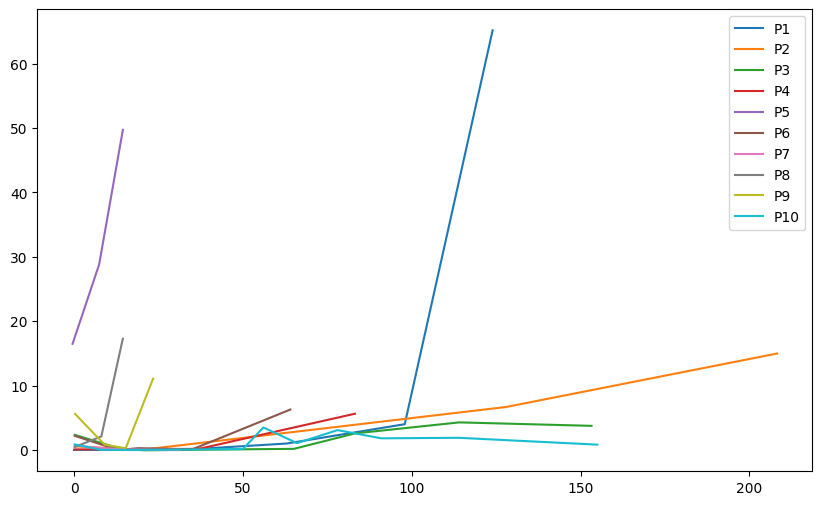

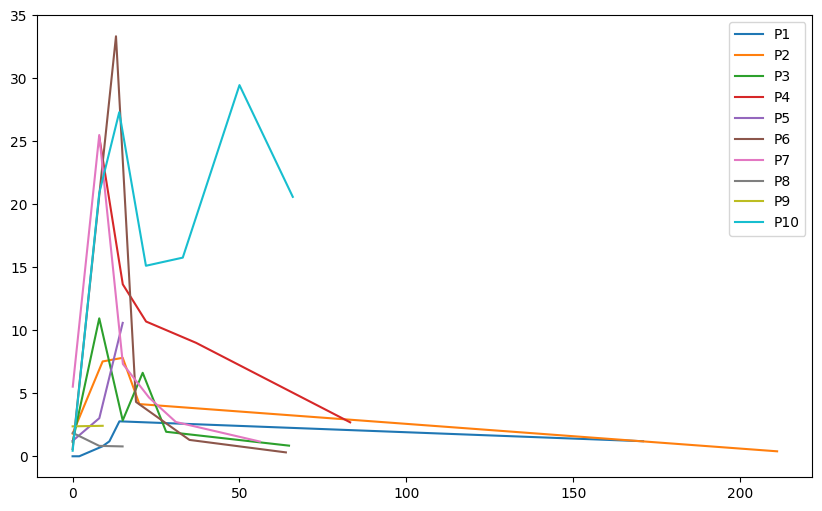

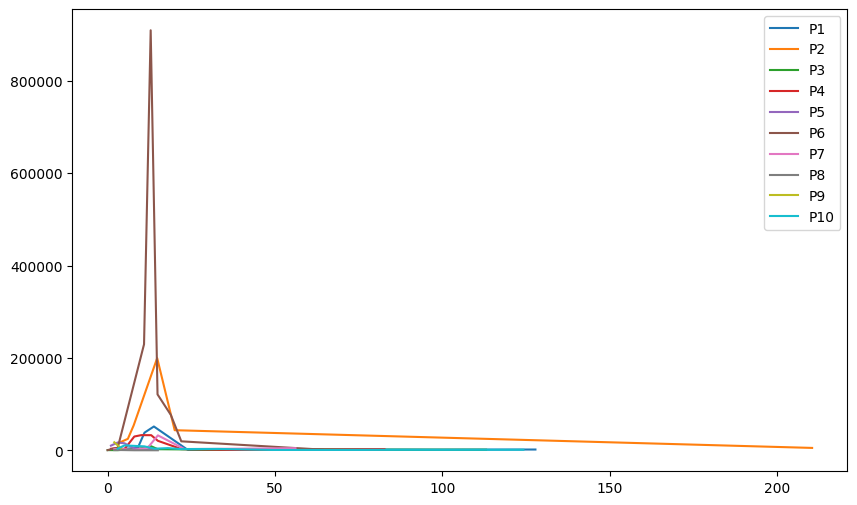

In [41]:
for ts_group in [ts_2b, ts_3a, ts_3b]:
    plt.figure(figsize=(10, 6))
    for pat in ts_group:
        ts = ts_group[pat]
        plt.plot(ts["day"], ts["y"], linestyle="-", label=pat)
    plt.legend()

## Look at data per patient

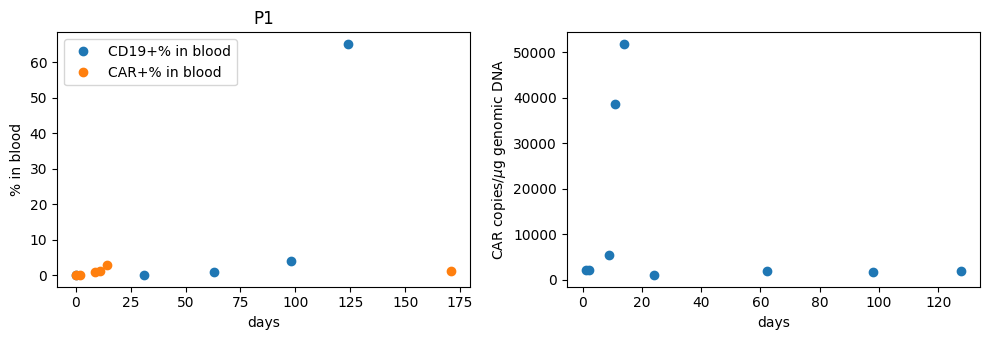

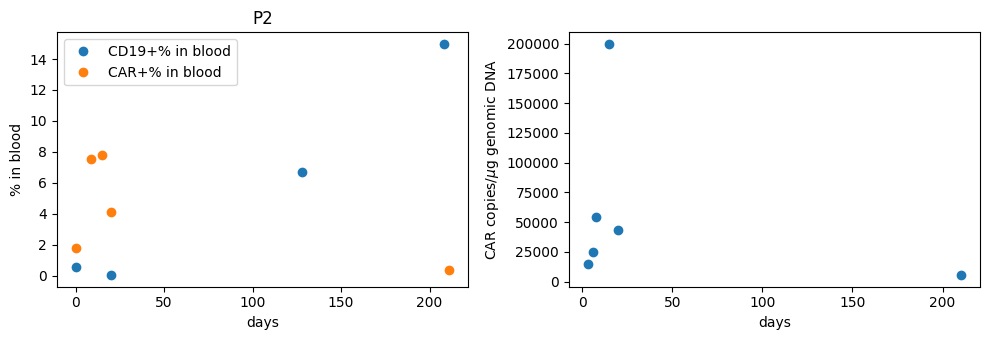

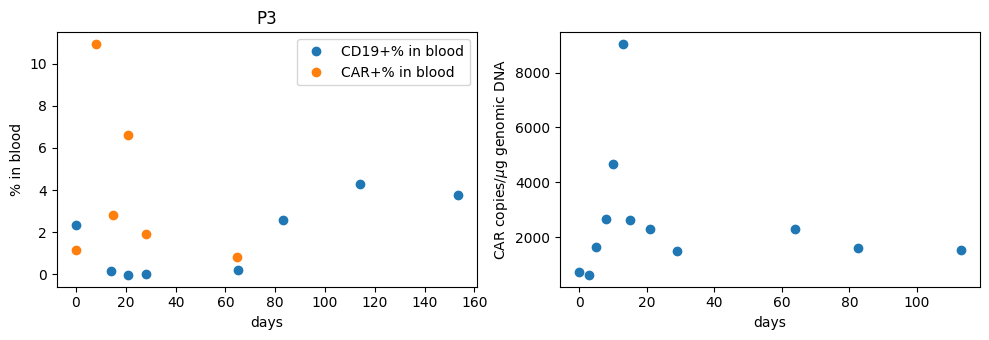

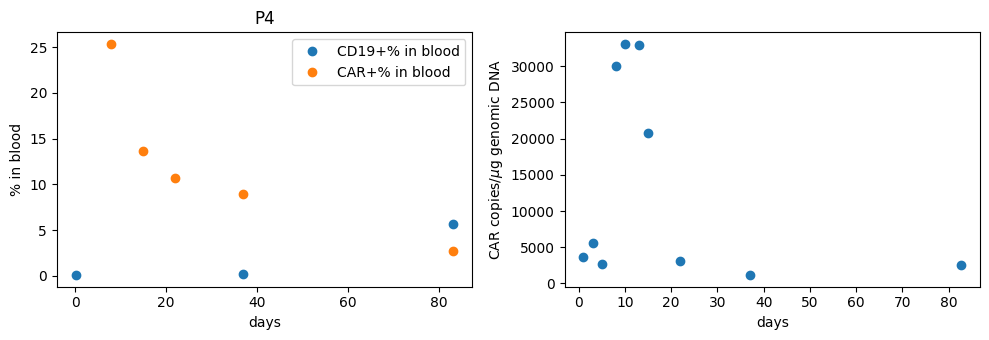

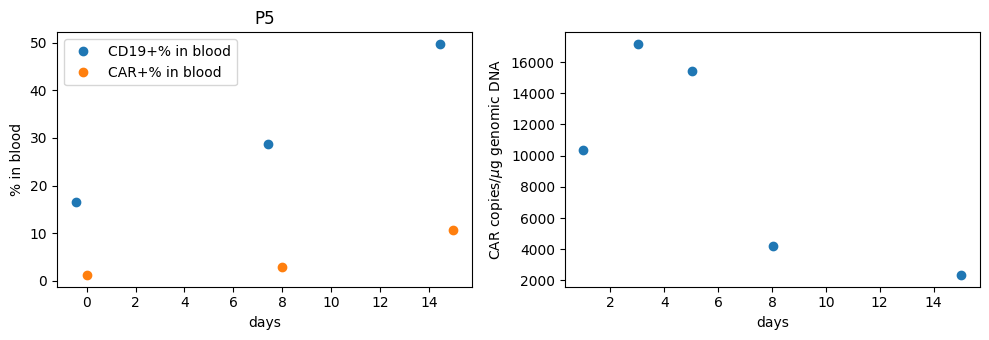

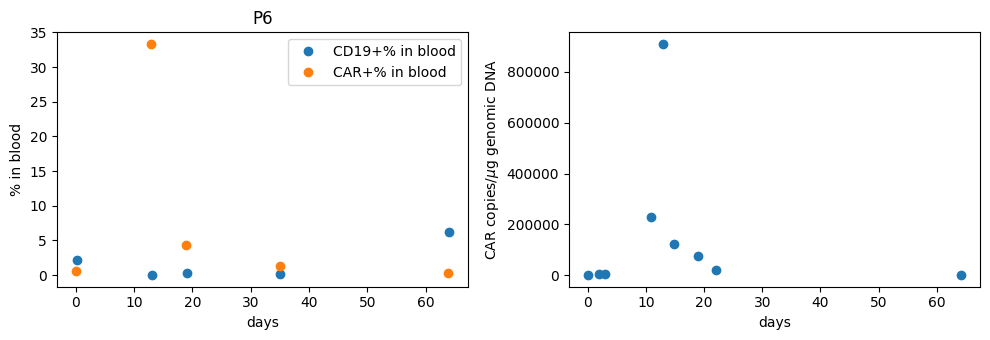

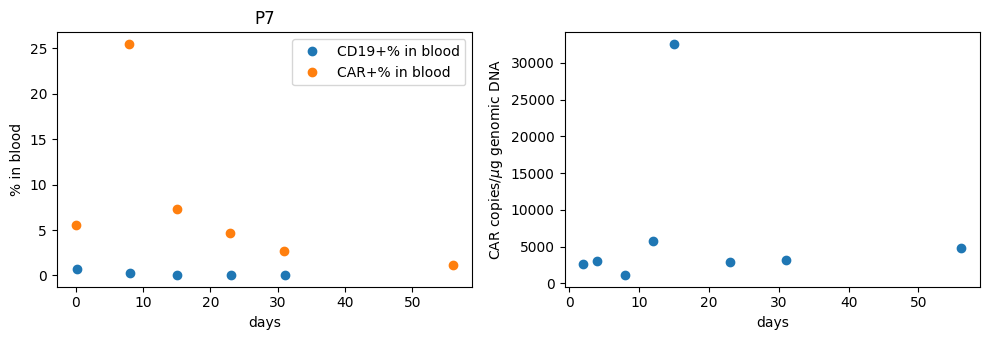

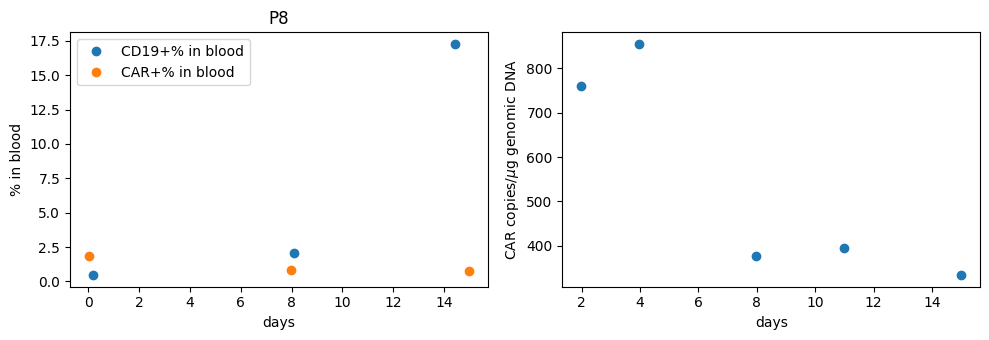

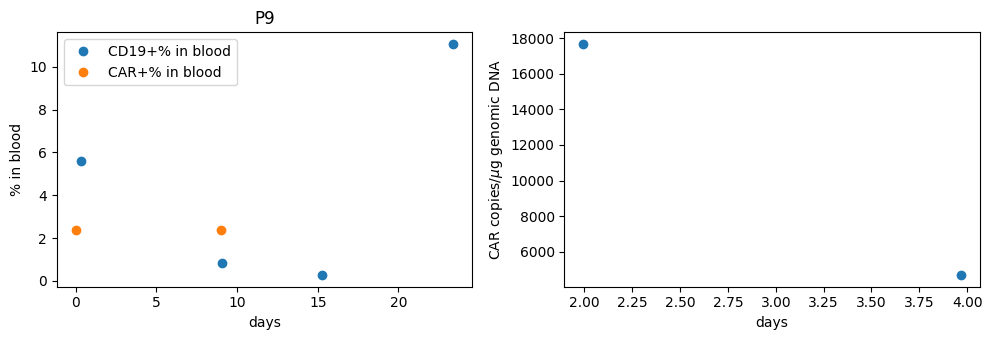

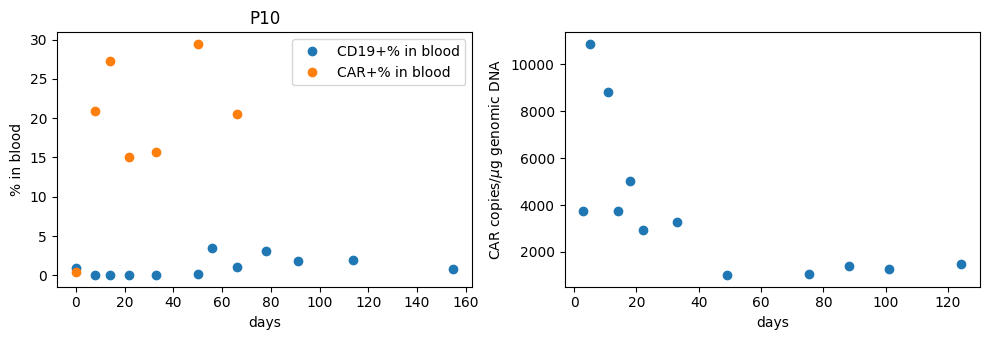

In [47]:
for pat in [f"P{n}" for n in range(1, 11)]:
    days_2b, y_2b = ts_2b[pat]["day"], ts_2b[pat]["y"]
    days_3a, y_3a = ts_3a[pat]["day"], ts_3a[pat]["y"]
    days_3b, y_3b = ts_3b[pat]["day"], ts_3b[pat]["y"]
    fig, axs = plt.subplots(1, 2)
    fig.set_figwidth(10)
    fig.set_figheight(3.5)
    axs[0].plot(days_2b, y_2b, "o", label=r"CD19+% in blood")
    axs[0].plot(days_3a, y_3a, "o", label=r"CAR+% in blood")
    axs[0].set_xlabel("days")
    axs[0].set_ylabel(r"% in blood")
    axs[0].set_title(pat)
    axs[0].legend()
    axs[1].plot(days_3b, y_3b, "o")
    axs[1].set_xlabel("days")
    axs[1].set_ylabel(r"CAR copies/$\mu$g genomic DNA")
    plt.tight_layout()
plt.show()